<a href="https://colab.research.google.com/github/Lourdes-Churacutipa/Repositorio-de-lourdes/blob/main/Lab6_Ses3_IslaCalor_GEE_editado(Easter_egg).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Portada CDA](https://drive.google.com/uc?export=view&id=1U9hCpCqZyqnCwjMACrD_YgUdJSNPrEFZ)

# Ejercicio: Islas de Calor Urbanas con Google Earth Engine
## Lima Metropolitana — Landsat 8/9 y MODIS

**Maestría en Ciencia de Datos Ambientales | UTEC**

---

Las **islas de calor urbanas** (UHI, *Urban Heat Island*) ocurren cuando las ciudades
registran temperaturas significativamente más altas que las zonas rurales circundantes.
Las superficies impermeables (asfalto, concreto), la falta de vegetación y el calor
generado por actividades humanas elevan la temperatura superficial urbana.

**Lima** es un caso de estudio interesante: ciudad costera desértica, con un gradiente
térmico marcado entre el centro urbano, los distritos periféricos y el litoral.

### Fuentes satelitales

| Satélite | Producto | Resolución espacial | Resolución temporal |
|---|---|---|---|
| **Landsat 8/9** | ST_B10 — Land Surface Temperature | **30 m** | ~16 días |
| **MODIS Terra** | MOD11A2 — LST & Emissivity | **1,000 m** | 8 días (compuesto) |

### Objetivos
1. Obtener y procesar temperatura superficial terrestre (LST) con dos sensores
2. Comparar la resolución espacial de Landsat vs MODIS
3. Cuantificar la intensidad de la isla de calor urbana en Lima
4. Identificar los distritos más calientes


---
## 1. Configuración de Google Earth Engine


In [5]:
# Autenticación y conexión a GEE (solo la primera vez en Colab)
import ee
import geemap
import matplotlib.pyplot as plt
import pandas as pd

try:
    ee.Initialize(project="ee-lchuracutipa")  # reemplaza con tu proyecto GEE ee-cmillanarancibia o utec-ingambiental-01
except Exception:
    ee.Authenticate()
    ee.Initialize(project="ee-lchuarcutipa")

print("GEE conectado correctamente")

GEE conectado correctamente


---
## 2. Área de estudio — Lima Metropolitana

Para delimitar el área de estudio usamos el dataset **FAO GAUL**
(*Global Administrative Unit Layers*), disponible de forma nativa en GEE.

> Fuente: [FAO GAUL — data.apps.fao.org](https://data.apps.fao.org/?lang=es)

| Nivel | Ruta GEE | Unidad administrativa en Perú |
|---|---|---|
| Level 0 | `FAO/GAUL_SIMPLIFIED_500m/2015/level0` | País |
| Level 1 | `FAO/GAUL_SIMPLIFIED_500m/2015/level1` | Departamentos |
| Level 2 | `FAO/GAUL_SIMPLIFIED_500m/2015/level2` | Provincias |

Usamos la versión **SIMPLIFIED_500m** (geometrías simplificadas a 500 m),
que carga más rápido y es suficiente para análisis a escala regional.

**Geometrías que definimos:**
- **`lima_prov`** — Provincia de Lima (≈ Lima Metropolitana), límite GAUL oficial
- **`zona_urbana`** — Núcleo urbano denso (Lima Centro, Miraflores, San Isidro)
- **`zona_periurbana`** — Periferia este (Cieneguilla / Lurín, menor densidad)


In [6]:
# Explorar el dataset FAO GAUL para Perú
# Level 1 = Departamentos | Level 2 = Provincias

gaul_l1 = (ee.FeatureCollection("FAO/GAUL_SIMPLIFIED_500m/2015/level1")
    .filter(ee.Filter.eq("ADM0_NAME", "Peru")))
gaul_l2 = (ee.FeatureCollection("FAO/GAUL_SIMPLIFIED_500m/2015/level2")
    .filter(ee.Filter.eq("ADM0_NAME", "Peru")))

print("Campos disponibles:")
print(gaul_l1.first().propertyNames().getInfo())

print(f"Departamentos ({gaul_l1.size().getInfo()}):")
deptos = gaul_l1.aggregate_array("ADM1_NAME").sort().getInfo()
for d in deptos:
    print(f"  {d}")

Campos disponibles:
['Shape_Leng', 'ADM1_CODE', 'STATUS', 'ADM0_NAME', 'ADM0_CODE', 'EXP1_YEAR', 'Shape_Area', 'system:index', 'ADM1_NAME', 'STR1_YEAR', 'DISP_AREA']
Departamentos (25):
  Amazonas
  Ancash
  Apurímac
  Arequipa
  Ayacucho
  Cajamarca
  Callao
  Cusco
  Huancavelica
  Huánuco
  Ica
  Junín
  La Libertad
  Lambayeque
  Lima
  Loreto
  Madre de Dios
  Moquegua
  Pasco
  Piura
  Puno
  San Martín
  Tacna
  Tumbes
  Ucayali


In [7]:
provs_lima = (gaul_l2
    .filter(ee.Filter.eq("ADM1_NAME", "Lima"))
    .aggregate_array("ADM2_NAME").sort().getInfo())
print(f"Provincias del departamento de Lima ({len(provs_lima)}):")
for p in provs_lima:
    print(f"  {p}")

Provincias del departamento de Lima (10):
  Barranca
  Cajatambo
  Canta
  Cañete
  Huaral
  Huarochiri
  Huaura
  Lima
  Oyon
  Yauyos


In [15]:
# Provincia de Lima — límites FAO GAUL Simplified 500m
gaul_l2

lima_prov = (gaul_l2
    .filter(ee.Filter.eq("ADM1_NAME", "Lima")))

lima_metro = (gaul_l2
    #.filter(ee.Filter.eq("ADM1_NAME", "Lima"))
    .filter(ee.Filter.eq("ADM2_NAME", "Lima"))
    .geometry())  # AOI para filtrar imágenes satelitales

# Zona urbana densa: Lima metropolitana (más pavimento, más edificios)
zona_urbana = lima_metro

# Zona periurbana: Provincia de Huarochiri (más rural, menos pavimento)
zona_periurbana = (gaul_l2
    .filter(ee.Filter.eq("ADM1_NAME", "Lima"))
    .filter(ee.Filter.eq("ADM2_NAME", "Huarochiri"))
    .geometry()
    )


area_km2 = lima_metro.area().divide(1e6).getInfo()
print(f"Provincia de Lima : {area_km2:.0f} km²")
print(f"Zona urbana       : {zona_urbana.area().getInfo()/1e6:.0f} km²")
print(f"Zona periurbana   : {zona_periurbana.area().getInfo()/1e6:.0f} km²")

# Mapa de verificación
Map0 = geemap.Map(center=[-12.1, -77.0], zoom=9)
Map0.addLayer(gaul_l2,       {"color": "purple"}, "Provincia2 Lima (GAUL)")
Map0.addLayer(lima_prov,       {"color": "gray"}, "Provincia Lima (GAUL)")
Map0.addLayer(zona_urbana,     {"color": "red"},  "Zona urbana")
Map0.addLayer(zona_periurbana, {"color": "green"},"Zona periurbana")
Map0

Provincia de Lima : 2711 km²
Zona urbana       : 2711 km²
Zona periurbana   : 5760 km²


Map(center=[-12.1, -77.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

---
## 3. Fuente 1 — Landsat 8/9: Temperatura Superficial a 30 m

**Producto:** `LANDSAT/LC08/C02/T1_L2` y `LANDSAT/LC09/C02/T1_L2`

La banda `ST_B10` contiene la temperatura superficial en unidades DN.
La conversión a grados Celsius es:

$$T_{\text{°C}} = (DN \times 0.00341802 + 149.0) - 273.15$$

> Usamos la **estación seca** (junio–agosto) para minimizar nubes en Lima.


In [16]:
# Función para convertir ST_B10 a °C y enmascarar nubes
def procesar_landsat(img):
    # Máscara de nubes con QA_PIXEL (bits 3 y 4 = nube y sombra)
    qa = img.select("QA_PIXEL")
    mascara = qa.bitwiseAnd(1 << 3).eq(0).And(qa.bitwiseAnd(1 << 4).eq(0))
    # Convertir ST_B10 a Celsius
    lst = (img.select("ST_B10")
              .multiply(0.00341802)
              .add(149.0)
              .subtract(273.15) # convertir de Kelvin a Celsius
              .updateMask(mascara)
              .rename("LST_C"))
    return lst.copyProperties(img, ["system:time_start"])

# Cargar Landsat 8 + 9 (estación seca 2025-2026)
l8 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
l9 = ee.ImageCollection("LANDSAT/LC09/C02/T1_L2")


## sacar representativo para ese año

landsat_lst = (l8.merge(l9)
    .filterBounds(lima_prov)  # todo el departamento de Lima
    .filter(ee.Filter.calendarRange(6, 8, "month"))  # jun-ago
    .filter(ee.Filter.calendarRange(2025, 2026, "year"))
    .filter(ee.Filter.lt("CLOUD_COVER", 30))
    .map(procesar_landsat)
    .median())

n_imgs = (l8.merge(l9)
    .filterBounds(lima_prov)
    .filter(ee.Filter.calendarRange(6, 8, "month"))
    .filter(ee.Filter.calendarRange(2025, 2026, "year"))
    .filter(ee.Filter.lt("CLOUD_COVER", 30))
    .size().getInfo())

print(f"Imágenes Landsat 8+9 disponibles: {n_imgs}")
print("Composición: mediana de la estación seca (jun-ago 2025-2026)")

Imágenes Landsat 8+9 disponibles: 64
Composición: mediana de la estación seca (jun-ago 2025-2026)


In [23]:
# Mapa interactivo — LST Landsat 30 m
Map1 = geemap.Map(center=[-12.1, -77.0], zoom=10, basemap= "Esri.WorldTopoMap")

vis_lst = {"min": 15, "max": 45, "palette": [
    "040274", "040281", "0502a3", "0502b8", "0602ff",
    "235cb1", "307ef3", "269db1", "30c8e2", "32d3ef",
    "3be285", "3ff38f", "86e26f", "3ae237", "b5e22e",
    "d6e21f", "fff705", "ffd611", "ffb613", "ff8b13",
    "ff6e08", "ff500d", "ff0000", "de0101", "c21301"
]}

Map1.addLayer(landsat_lst.clip(lima_prov), vis_lst, "LST Landsat 30m (°C)")
Map1.addLayer(zona_urbana,    {"color": "red"},   "Zona urbana")
Map1.addLayer(zona_periurbana, {"color": "green"}, "Zona periurbana")
Map1.add_colorbar(vis_lst, label="Temperatura superficial (°C)")
Map1

Map(center=[-12.1, -77.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

---
## 4. Fuente 2 — MODIS Terra: Temperatura Superficial a 1 km

**Producto:** `MODIS/061/MOD11A2` — compuesto de 8 días

La banda `LST_Day_1km` contiene la temperatura diurna en Kelvin × 50.
La conversión a Celsius es:

$$T_{\text{°C}} = (DN \times 0.02) - 273.15$$

> MODIS tiene **menor resolución** pero mayor **cobertura temporal** — útil para
> seguir la variación estacional de la UHI a lo largo del año.


In [27]:
# Cargar MODIS MOD11A2 — LST diurna de 8 días
def procesar_modis(img):
    lst = (img.select("LST_Day_1km")
              .multiply(0.02)
              .subtract(273.15)
              .rename("LST_C"))
    # Máscara de calidad (bits 0-1: 00 = buena calidad)
    qc = img.select("QC_Day")
    mascara = qc.bitwiseAnd(3).eq(0)
    return lst.updateMask(mascara).copyProperties(img, ["system:time_start"])

modis_lst = (ee.ImageCollection("MODIS/061/MOD11A2")
    .filterBounds(lima_metro)
    .filter(ee.Filter.calendarRange(5, 8, "month"))  # ene-mar (verano)
    .filter(ee.Filter.calendarRange(2025, 2026, "year"))
    .map(procesar_modis)
    .mean())

n_modis = (ee.ImageCollection("MODIS/061/MOD11A2")
    .filterBounds(lima_metro)
    .filter(ee.Filter.calendarRange(5, 8, "month"))
    .filter(ee.Filter.calendarRange(2025, 2026, "year"))
    .size().getInfo())

print(f"Compuestos MODIS disponibles: {n_modis}")
print("Composición: promedio del verano austral (ene-mar 2022-2023)")

Compuestos MODIS disponibles: 32
Composición: promedio del verano austral (ene-mar 2022-2023)


In [28]:
# Mapa interactivo — LST MODIS 1 km
Map2 = geemap.Map(center=[-12.1, -77.0], zoom=10, basemap= "Esri.WorldTopoMap")

Map2.addLayer(modis_lst.clip(lima_prov), vis_lst, "LST MODIS 1km (°C)")
Map2.addLayer(zona_urbana,    {"color": "red"},   "Zona urbana")
Map2.addLayer(zona_periurbana, {"color": "green"}, "Zona periurbana")
Map2.add_colorbar(vis_lst, label="Temperatura superficial (°C)")
Map2

Map(center=[-12.1, -77.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

---
## 5. Comparación Landsat vs MODIS

Ambos sensores miden LST pero con distintas fortalezas:

| | Landsat 8/9 | MODIS |
|---|---|---|
| Resolución | **30 m** — distingue calles y parques | **1,000 m** — solo grandes patrones |
| Revisita | 16 días | 8 días (compuesto) |
| Nubes | Más afectado — solo imágenes claras | Menos afectado — promedia más imágenes |
| Uso ideal | Análisis intraurbano fino | Series de tiempo, variación estacional |


In [29]:
# Mapa comparativo lado a lado
Map3 = geemap.Map(center=[-12.1, -77.0], zoom=10, basemap= "Esri.WorldTopoMap")

Map3.split_map(
    left_layer=geemap.ee_tile_layer(landsat_lst.clip(lima_prov), vis_lst, "Landsat 30m"),
    right_layer=geemap.ee_tile_layer(modis_lst.clip(lima_prov),  vis_lst, "MODIS 1km")
)
Map3

Map(center=[-12.1, -77.0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_o…

---
## 6. Intensidad de la Isla de Calor Urbana (UHI)

La **intensidad UHI** se define como la diferencia de temperatura entre la zona urbana densa y una zona de referencia periurbana o rural:

$$\text{UHI} = \overline{T}_{\text{urbana}} - \overline{T}_{\text{periurbana}}$$

Calculamos esto con **ambas fuentes** y comparamos los resultados.


In [30]:
# Función para extraer LST media en una zona
def lst_media(imagen, geometria, escala, nombre):
    stats = imagen.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geometria,
        scale=escala,
        maxPixels=1e9
    )
    return stats.get("LST_C").getInfo()

# --- Landsat (escala 30m) ---
lst_urb_l8  = lst_media(landsat_lst, zona_urbana,    30,  "Landsat-Urbana")
lst_peri_l8 = lst_media(landsat_lst, zona_periurbana, 30, "Landsat-Periurbana")

# --- MODIS (escala 1000m) ---
lst_urb_mod  = lst_media(modis_lst, zona_urbana,    1000, "MODIS-Urbana")
lst_peri_mod = lst_media(modis_lst, zona_periurbana, 1000, "MODIS-Periurbana")

print("=" * 50)
print(f"  Fuente       Urbana (C)  Periurbana (C)   UHI (C)")
print("-" * 50)
print(f"  Landsat    {lst_urb_l8:>10.2f}  {lst_peri_l8:>14.2f}  {lst_urb_l8 - lst_peri_l8:>+9.2f}")
print(f"  MODIS      {lst_urb_mod:>10.2f}  {lst_peri_mod:>14.2f}  {lst_urb_mod - lst_peri_mod:>+9.2f}")
print("=" * 50)

  Fuente       Urbana (C)  Periurbana (C)   UHI (C)
--------------------------------------------------
  Landsat         28.04           27.10      +0.95
  MODIS           27.00           16.10     +10.90


In [31]:
# Imagen de diferencia: urbana - periurbana (UHI espacial con Landsat)
# Referencia: LST media de la zona periurbana como baseline
lst_ref = ee.Number(lst_peri_l8)
uhi_map = landsat_lst.subtract(lst_ref).rename("UHI_C")

vis_uhi = {
    "min": -10, "max": 15,
    "palette": ["blue", "white", "yellow", "orange", "red", "darkred"]
}

Map4 = geemap.Map(center=[-12.1, -77.0], zoom=10, basemap= "Esri.WorldTopoMap")
Map4.addLayer(uhi_map.clip(lima_prov), vis_uhi, "Intensidad UHI (°C sobre referencia)")
Map4.addLayer(zona_urbana,    {"color": "red"},   "Zona urbana")
Map4.addLayer(zona_periurbana, {"color": "green"}, "Zona periurbana")
Map4.add_colorbar(vis_uhi, label="ΔT respecto a zona periurbana (°C)")
Map4

Map(center=[-12.1, -77.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

---
## 7. Variación estacional de la UHI — serie mensual

MODIS permite calcular la intensidad UHI **mes a mes** a lo largo del año.
Complementamos con **Landsat 8/9** para comparar la señal entre sensores
y estimar el sesgo entre resoluciones espaciales (30 m vs 1 km).

| Sensor | Período | Escala | Nota |
|---|---|---|---|
| **Landsat 8/9** | 2013–2025 | 30 m | Mediana mensual, solo escenas < 30% nubes |
| **MODIS MOD11A2** | 2013–2025 | 1 km | Promedio de compuestos de 8 días |


### 7.1 Landsat 8/9 — climatología mensual (2013–2023)

Para cada mes del año promediamos todas las imágenes Landsat 8+9 disponibles
entre 2013 y 2023 con cobertura de nubes < 30 %.


Calculando serie Landsat (puede tomar ~2-3 min)...


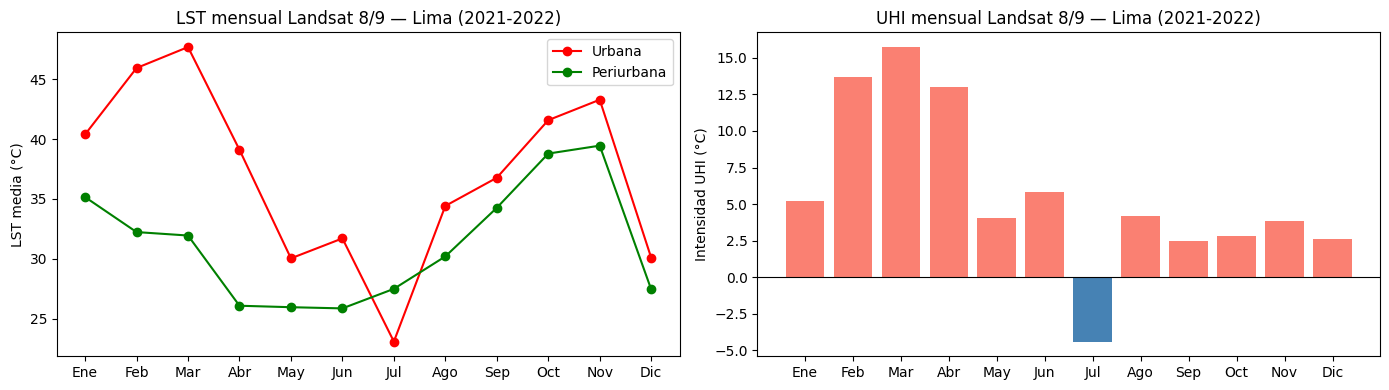

Mes más caliente (ciudad) : Mar
Mayor intensidad UHI (L8) : Mar (15.7 °C)


In [35]:
# UHI mensual con Landsat 8/9 — climatología 2021-2022 (Luego puedes intenter para toda las serie disponibe 2013-2026)
# (puede tomar 2-3 minutos — GEE procesa ~120 escenas)
def uhi_mensual_landsat(mes):
    col = (l8.merge(l9)
           .filter(ee.Filter.calendarRange(mes, mes, "month"))
           .filter(ee.Filter.calendarRange(2022, 2023, "year"))
           .filter(ee.Filter.lt("CLOUD_COVER", 30))
           .map(procesar_landsat)
           .median())
    urb  = col.reduceRegion(ee.Reducer.mean(), zona_urbana,     30, maxPixels=1e9).get("LST_C").getInfo()
    peri = col.reduceRegion(ee.Reducer.mean(), zona_periurbana, 30, maxPixels=1e9).get("LST_C").getInfo()
    return {"mes": mes, "urb": urb, "peri": peri,
            "uhi": (urb - peri) if urb and peri else None}

print("Calculando serie Landsat (puede tomar ~2-3 min)...")
res_l8 = [uhi_mensual_landsat(m) for m in range(1, 13)]
df_l8 = pd.DataFrame(res_l8)

meses_es = ["Ene","Feb","Mar","Abr","May","Jun",
            "Jul","Ago","Sep","Oct","Nov","Dic"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(range(1,13), df_l8["urb"],  "ro-", label="Urbana")
axes[0].plot(range(1,13), df_l8["peri"], "go-", label="Periurbana")
axes[0].set_xticks(range(1,13)); axes[0].set_xticklabels(meses_es)
axes[0].set_ylabel("LST media (°C)"); axes[0].legend()
axes[0].set_title("LST mensual Landsat 8/9 — Lima (2021-2022)")

axes[1].bar(range(1,13), df_l8["uhi"],
            color=["salmon" if v and v > 0 else "steelblue" for v in df_l8["uhi"]])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xticks(range(1,13)); axes[1].set_xticklabels(meses_es)
axes[1].set_ylabel("Intensidad UHI (°C)")
axes[1].set_title("UHI mensual Landsat 8/9 — Lima (2021-2022)")
plt.tight_layout(); plt.show()

print(f"Mes más caliente (ciudad) : {meses_es[df_l8['urb'].idxmax()]}")
print(f"Mayor intensidad UHI (L8) : {meses_es[df_l8['uhi'].idxmax()]} ({df_l8['uhi'].max():.1f} °C)")

In [ ]:
df_l8

,mes,urb,peri,uhi
0,1,41.865433,29.743833,12.121601
1,2,38.110466,19.629974,18.480492
2,3,43.687032,25.339569,18.347463
3,4,38.861392,25.507892,13.353500
4,5,34.061625,26.478096,7.583529
5,6,31.159919,24.947019,6.212900
6,7,24.870135,26.855663,-1.985528
7,8,34.156254,30.326464,3.829790
8,9,38.430127,36.031797,2.398330
9,10,41.437914,38.230051,3.207864


### 7.2 MODIS — climatología mensual (2013–2023)

Mismo período que Landsat para que la comparación sea consistente.


Calculando serie MODIS...


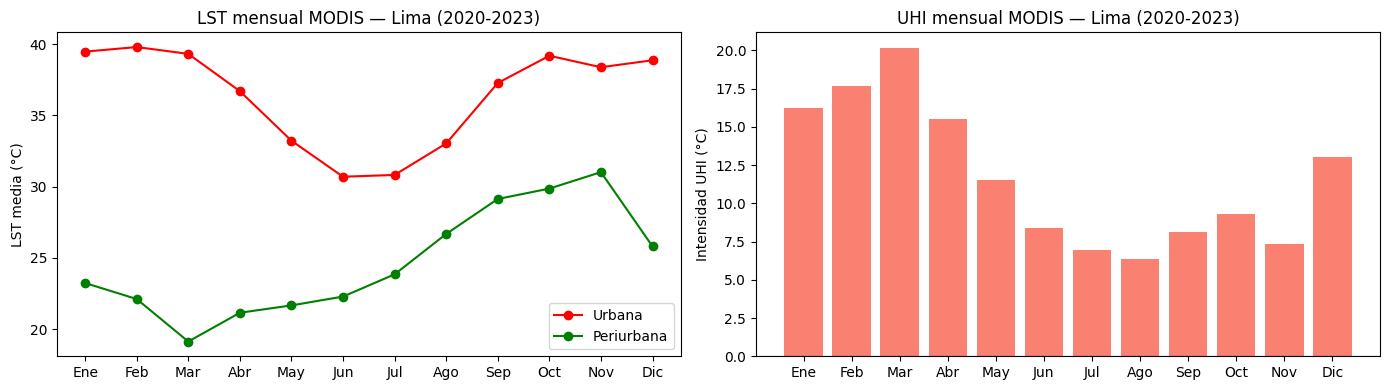

Mes más caliente (ciudad) : Feb
Mayor intensidad UHI (MOD): Mar (20.2 °C)


In [36]:
# UHI mensual con MODIS MOD11A2 — climatología 2020-2023
def uhi_mensual(mes):
    col = (ee.ImageCollection("MODIS/061/MOD11A2")
           .filter(ee.Filter.calendarRange(mes, mes, "month"))
           .filter(ee.Filter.calendarRange(2020, 2023, "year"))
           .map(procesar_modis)
           .mean())
    urb  = col.reduceRegion(ee.Reducer.mean(), zona_urbana,     1000, maxPixels=1e9).get("LST_C").getInfo()
    peri = col.reduceRegion(ee.Reducer.mean(), zona_periurbana, 1000, maxPixels=1e9).get("LST_C").getInfo()
    return {"mes": mes, "urb": urb, "peri": peri,
            "uhi": (urb - peri) if urb and peri else None}

print("Calculando serie MODIS...")
resultados = [uhi_mensual(m) for m in range(1, 13)]
df_uhi = pd.DataFrame(resultados)

meses_es = ["Ene","Feb","Mar","Abr","May","Jun",
            "Jul","Ago","Sep","Oct","Nov","Dic"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(range(1,13), df_uhi["urb"],  "ro-", label="Urbana")
axes[0].plot(range(1,13), df_uhi["peri"], "go-", label="Periurbana")
axes[0].set_xticks(range(1,13)); axes[0].set_xticklabels(meses_es)
axes[0].set_ylabel("LST media (°C)"); axes[0].legend()
axes[0].set_title("LST mensual MODIS — Lima (2020-2023)")

axes[1].bar(range(1,13), df_uhi["uhi"],
            color=["salmon" if v and v > 0 else "steelblue" for v in df_uhi["uhi"]])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xticks(range(1,13)); axes[1].set_xticklabels(meses_es)
axes[1].set_ylabel("Intensidad UHI (°C)")
axes[1].set_title("UHI mensual MODIS — Lima (2020-2023)")
plt.tight_layout(); plt.show()

print(f"Mes más caliente (ciudad) : {meses_es[df_uhi['urb'].idxmax()]}")
print(f"Mayor intensidad UHI (MOD): {meses_es[df_uhi['uhi'].idxmax()]} ({df_uhi['uhi'].max():.1f} °C)")

In [ ]:
df_uhi

,mes,urb,peri,uhi
0,1,39.467711,23.239538,16.228173
1,2,39.788296,22.119054,17.669242
2,3,39.310132,19.137433,20.172699
3,4,36.694306,21.157334,15.536972
4,5,33.220457,21.672748,11.547709
5,6,30.694925,22.291677,8.403248
6,7,30.821030,23.851646,6.969384
7,8,33.029954,26.681087,6.348867
8,9,37.265917,29.136137,8.129780
9,10,39.179896,29.863694,9.316202


### 7.3 Comparación Landsat vs MODIS

Graficamos ambas series juntas para identificar **sesgo sistemático** entre sensores.
Un sesgo constante sugiere diferencias en resolución espacial o en la función de
respuesta espectral. Una discrepancia estacional indica que uno de los sensores
captura mejor ciertos procesos (ej. garúa, nubosidad, mezcla de pixeles).


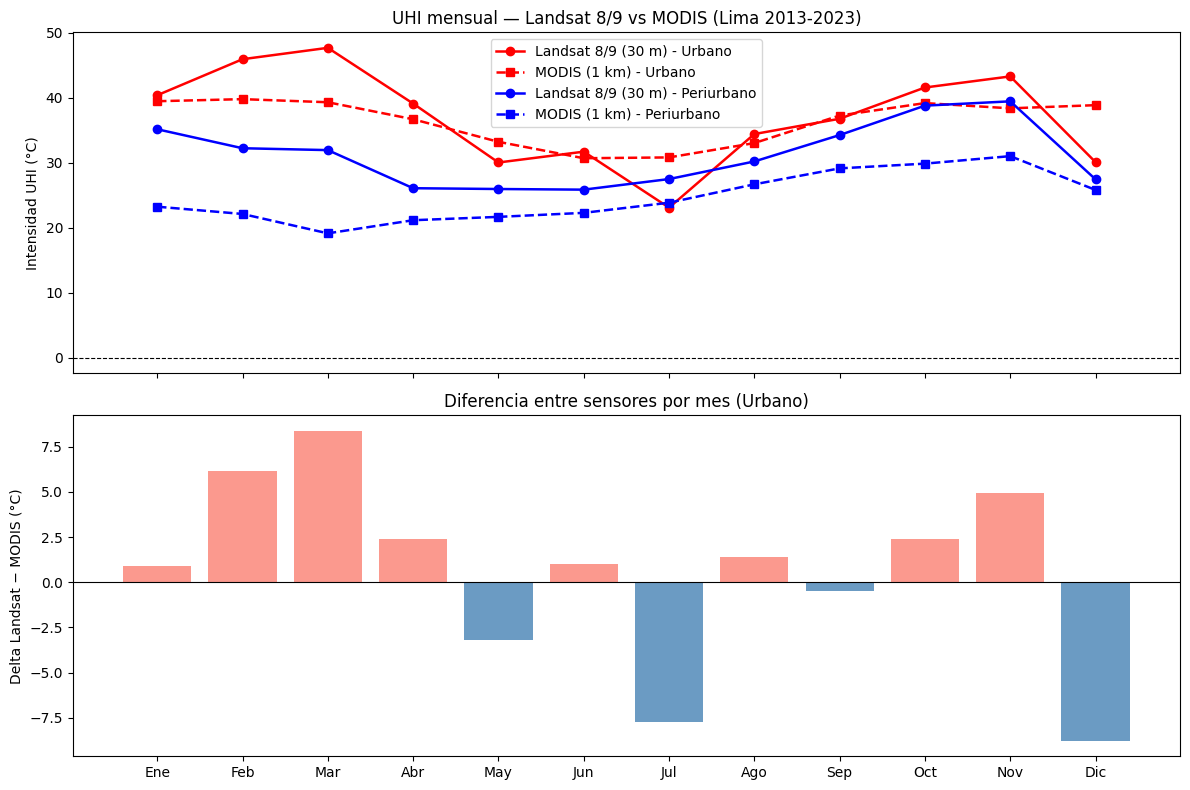

In [37]:
# Comparación Landsat vs MODIS — UHI mensual
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# ── Panel superior: UHI de ambos sensores ────────────────────────────────
uhi_l8    = df_l8["uhi"].tolist()
uhi_modis = df_uhi["uhi"].tolist()

# Urbano
axes[0].plot(range(1,13), df_l8['urb'],    "ro-", # Rojo, círculos, línea sólida (Landsat)
             linewidth=1.8, label="Landsat 8/9 (30 m) - Urbano")
axes[0].plot(range(1,13), df_uhi['urb'], "rs--", # Rojo, cuadrados, línea punteada (MODIS)
             linewidth=1.8, label="MODIS (1 km) - Urbano")

#Peri-urbano
axes[0].plot(range(1,13), df_l8['peri'],    "bo-",# Azul, círculos, línea sólida (Landsat)
             linewidth=1.8, label="Landsat 8/9 (30 m) - Periurbano")
axes[0].plot(range(1,13), df_uhi['peri'], "bs--",# Azul, cuadrados, línea punteada (MODIS)
             linewidth=1.8, label="MODIS (1 km) - Periurbano")

axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_ylabel("Intensidad UHI (°C)")
axes[0].set_title("UHI mensual — Landsat 8/9 vs MODIS (Lima 2013-2023)")
axes[0].legend()

# ── Panel inferior: sesgo (Landsat - MODIS) ──────────────────────────────
sesgo = [l - m if l is not None and m is not None else 0
         for l, m in zip(df_l8['urb'], df_uhi['urb'])]
cols = ["salmon" if s > 0 else "steelblue" for s in sesgo]
axes[1].bar(range(1,13), sesgo, color=cols, alpha=0.8)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xticks(range(1,13)); axes[1].set_xticklabels(meses_es)
axes[1].set_ylabel("Delta Landsat − MODIS (°C)")
axes[1].set_title("Diferencia entre sensores por mes (Urbano)")

plt.tight_layout(); plt.show()


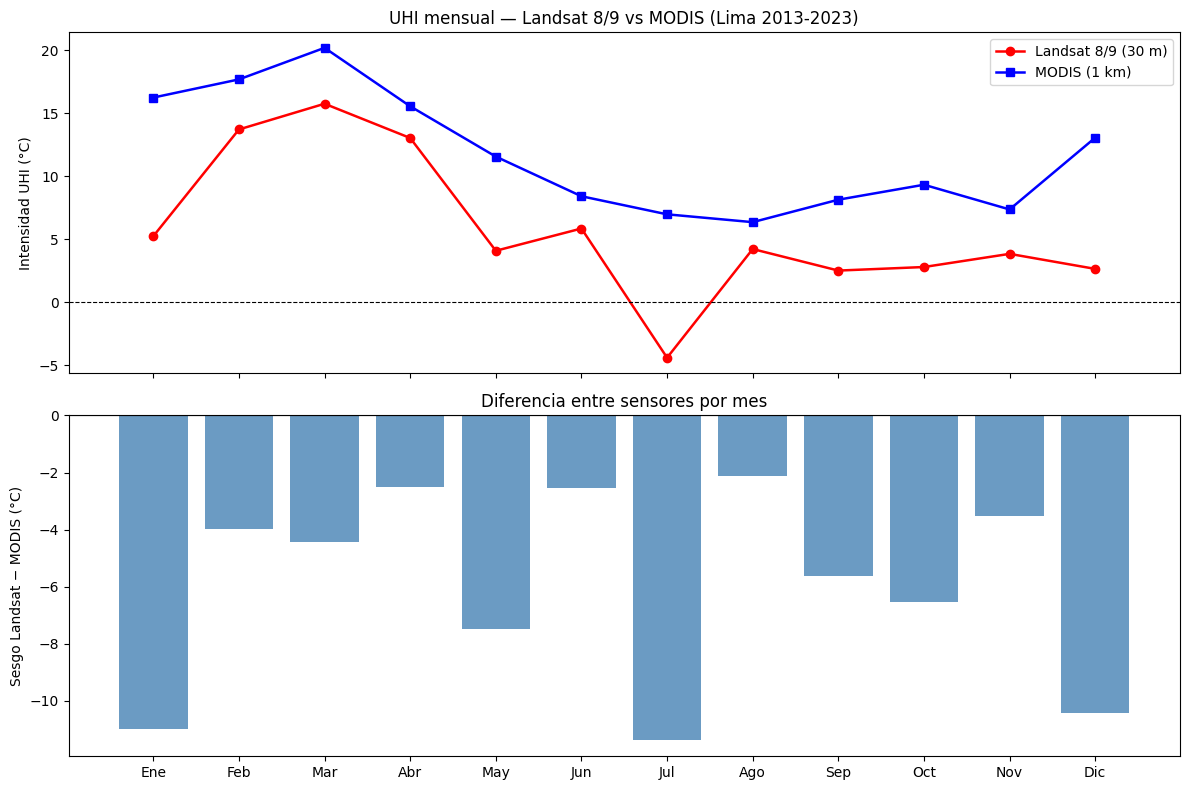

Sesgo medio anual   : -5.96 °C
Sesgo máximo        : -2.13 °C (Ago)
Sesgo mínimo        : -11.37 °C (Jul)
RMSE entre sensores : 6.79 °C


In [39]:
# Comparación Landsat vs MODIS — UHI mensual
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# ── Panel superior: UHI de ambos sensores ────────────────────────────────
uhi_l8    = df_l8["uhi"].tolist()
uhi_modis = df_uhi["uhi"].tolist()

axes[0].plot(range(1,13), uhi_l8,    "ro-", linewidth=1.8, label="Landsat 8/9 (30 m)")
axes[0].plot(range(1,13), uhi_modis, "bs-", linewidth=1.8, label="MODIS (1 km)")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_ylabel("Intensidad UHI (°C)")
axes[0].set_title("UHI mensual — Landsat 8/9 vs MODIS (Lima 2013-2023)")
axes[0].legend()

# ── Panel inferior: sesgo (Landsat - MODIS) ──────────────────────────────
sesgo = [l - m if l is not None and m is not None else 0
         for l, m in zip(uhi_l8, uhi_modis)]
cols = ["salmon" if s > 0 else "steelblue" for s in sesgo]
axes[1].bar(range(1,13), sesgo, color=cols, alpha=0.8)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xticks(range(1,13)); axes[1].set_xticklabels(meses_es)
axes[1].set_ylabel("Sesgo Landsat − MODIS (°C)")
axes[1].set_title("Diferencia entre sensores por mes")

plt.tight_layout(); plt.show()

# Estadísticas del sesgo
import numpy as np
sesgo_arr = np.array([s for s in sesgo if s != 0])
print(f"Sesgo medio anual   : {sesgo_arr.mean():.2f} °C")
print(f"Sesgo máximo        : {sesgo_arr.max():.2f} °C ({meses_es[np.argmax(sesgo)]})")
print(f"Sesgo mínimo        : {sesgo_arr.min():.2f} °C ({meses_es[np.argmin(sesgo)]})")
print(f"RMSE entre sensores : {np.sqrt((sesgo_arr**2).mean()):.2f} °C")

---
# TAREA: Isla de Calor Urbana en otra ciudad de Perú

## Enunciado

Replica el análisis en **una ciudad peruana de tu elección** y compara
el comportamiento de la UHI entre la **época seca** (jun–ago) y el **verano austral** (ene–mar).

**Ciudades sugeridas** (elige una):

| Ciudad | Región | Característica |
|---|---|---|
| Arequipa | Andes | Ciudad andina árida, 2,335 m |
| Trujillo | Costa norte | Clima árido + agroindustria |
| Iquitos | Amazonía | Ciudad tropical húmeda |
| Cusco | Andes | Ciudad andina húmeda, 3,400 m |
| Chiclayo | Costa norte | Ciudad costera desértica |

---

### Entregables

| # | Ítem | Pts |
|---|---|---|
| 1 | AOI de tu ciudad (GAUL o polígono) + mapa de ubicación | 1 |
| 2 | LST Landsat — **verano** (ene–mar): mapa y tabla UHI | 2 |
| 3 | LST Landsat — **época seca** (jun–ago): mapa y tabla UHI | 2 |
| 4 | LST MODIS — serie mensual de intensidad UHI (gráfico de barras) | 2 |
| 5 | Comparación: ¿la UHI es positiva o negativa según estación? ¿Por qué? | 2 |
| 6 | Conclusión: ¿Cómo se compara con Lima? | 1 |

**Total: 10 pts**

---

### Preguntas guía
- ¿Tu ciudad también muestra UHI negativa en invierno, como Lima?
- ¿En qué mes es mayor la intensidad UHI? ¿Coincide con la estación seca/lluviosa local?
- ¿Qué diferencias hay entre Landsat (30 m) y MODIS (1 km)? ¿Cuál muestra mejor el patrón intraurbano?

**Entregable:** `Tarea3_[Apellido]_UHI_[Ciudad].ipynb`
